# Análisis Inicial

En este documento se pretende analizar la información procesada. En la información procesada, se establecen las siguientes columnas:
- ENT: Entidad federativa
- REGION: Región
- EDAD_V: Edad del individuo
- P5_19: Salario Mensual del individuo
- P5_19A: Período en el que recibe su salario
- P5_21: Gastos mensuales
- P6_12: Capacidad de endeudamiento mensual
- factor: Corresponde al número de veces que se recibe el ingreso al mes
- salario_mensual: Ingreso mensual (Producto de factor y P5_19)
- P6_13: Target: Capacidad de pago mensual

A continuación, mostramos el análisis inicial para establecer las relaciones o patrones.

## Cargamos el data set procesado

In [36]:
# importamos librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

# Librería de visualización de datos: https://seaborn.pydata.org/
import seaborn as sns

# Establecemos el tema de las tables / graficas
sns.set_theme(style="whitegrid")

# Cargamos el data set procesado
df = pd.read_csv("../data/processed/processed.csv")

# Mostramos primeros registros 
df.head()


,ENT,REGION,EDAD_V,P5_21,P6_12,target,EDAD_V_unknown,P5_19_unknown,P5_21_unknown,P5_21_top,...,P6_12_unknown,P6_12_top,target_no_response,target_unknown,target_log,P5_19A_unknown,salario_mensual,salario_mensual_unknown,ratio_gasto_ingreso,ahorro
0,2,1,32.0,17000.0,5000.0,1000.0,False,False,False,False,...,False,False,False,False,6.908755,False,12000.0,False,1.416549,-5000.0
1,2,1,34.0,3000.0,5000.0,200.0,False,False,False,False,...,False,False,False,False,5.303305,False,7200.0,False,0.416609,4200.0
2,2,1,30.0,12000.0,10000.0,2000.0,False,False,False,False,...,False,False,False,False,7.601402,False,12000.0,False,0.999917,0.0
3,2,1,60.0,25000.0,50000.0,5000.0,False,False,False,False,...,False,False,False,False,8.517393,False,25000.0,False,0.999960,0.0
4,2,1,63.0,18000.0,25000.0,3000.0,False,True,False,False,...,False,False,False,False,8.006701,True,8000.0,True,2.249719,-10000.0


### Información general del data set procesado

In [37]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8548 entries, 0 to 8547
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ENT                      8548 non-null   int64  
 1   REGION                   8548 non-null   int64  
 2   EDAD_V                   8548 non-null   float64
 3   P5_21                    8548 non-null   float64
 4   P6_12                    8548 non-null   float64
 5   target                   8548 non-null   float64
 6   EDAD_V_unknown           8548 non-null   bool   
 7   P5_19_unknown            8548 non-null   bool   
 8   P5_21_unknown            8548 non-null   bool   
 9   P5_21_top                8548 non-null   bool   
 10  P6_12_no_response        8548 non-null   bool   
 11  P6_12_unknown            8548 non-null   bool   
 12  P6_12_top                8548 non-null   bool   
 13  target_no_response       8548 non-null   bool   
 14  target_unknown           8548 non-n

,ENT,REGION,EDAD_V,P5_21,P6_12,target,target_log,salario_mensual,ratio_gasto_ingreso,ahorro
count,8548.000000,8548.000000,8548.000000,8548.000000,8.548000e+03,8548.000000,8548.000000,8548.000000,8548.000000,8548.000000
mean,14.747777,1.649860,43.890852,7317.470285,8.585429e+04,2875.883599,6.216644,9946.513492,0.959069,2629.043207
std,9.930979,0.477042,16.644442,7471.799079,4.764380e+05,12386.740360,2.828440,11697.137871,1.538639,11340.438741
min,1.000000,1.000000,18.000000,0.000000,0.000000e+00,0.000000,0.000000,200.000000,0.000000,-95600.000000
25%,5.750000,1.000000,30.000000,3000.000000,3.500000e+03,300.000000,5.707110,6000.000000,0.428541,0.000000
50%,14.000000,2.000000,42.000000,5500.000000,1.000000e+04,1000.000000,6.908755,8000.000000,0.714235,2000.000000
75%,25.000000,2.000000,56.000000,9000.000000,4.000000e+04,3000.000000,8.006701,10000.000000,0.999875,5000.000000
max,32.000000,2.000000,97.000000,98000.000000,9.800000e+06,980000.000000,13.795309,392000.000000,50.746269,387000.000000


### Distribución del Target

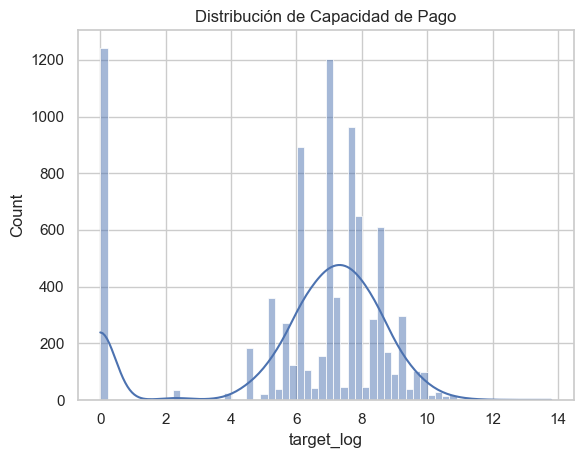

In [38]:
plt.figure()
sns.histplot(df["target_log"], kde=True)
plt.title("Distribución de Capacidad de Pago")
plt.show()

### Correlación
Correlación (Pearson) = qué tan bien una variable cambia en línea recta con otra

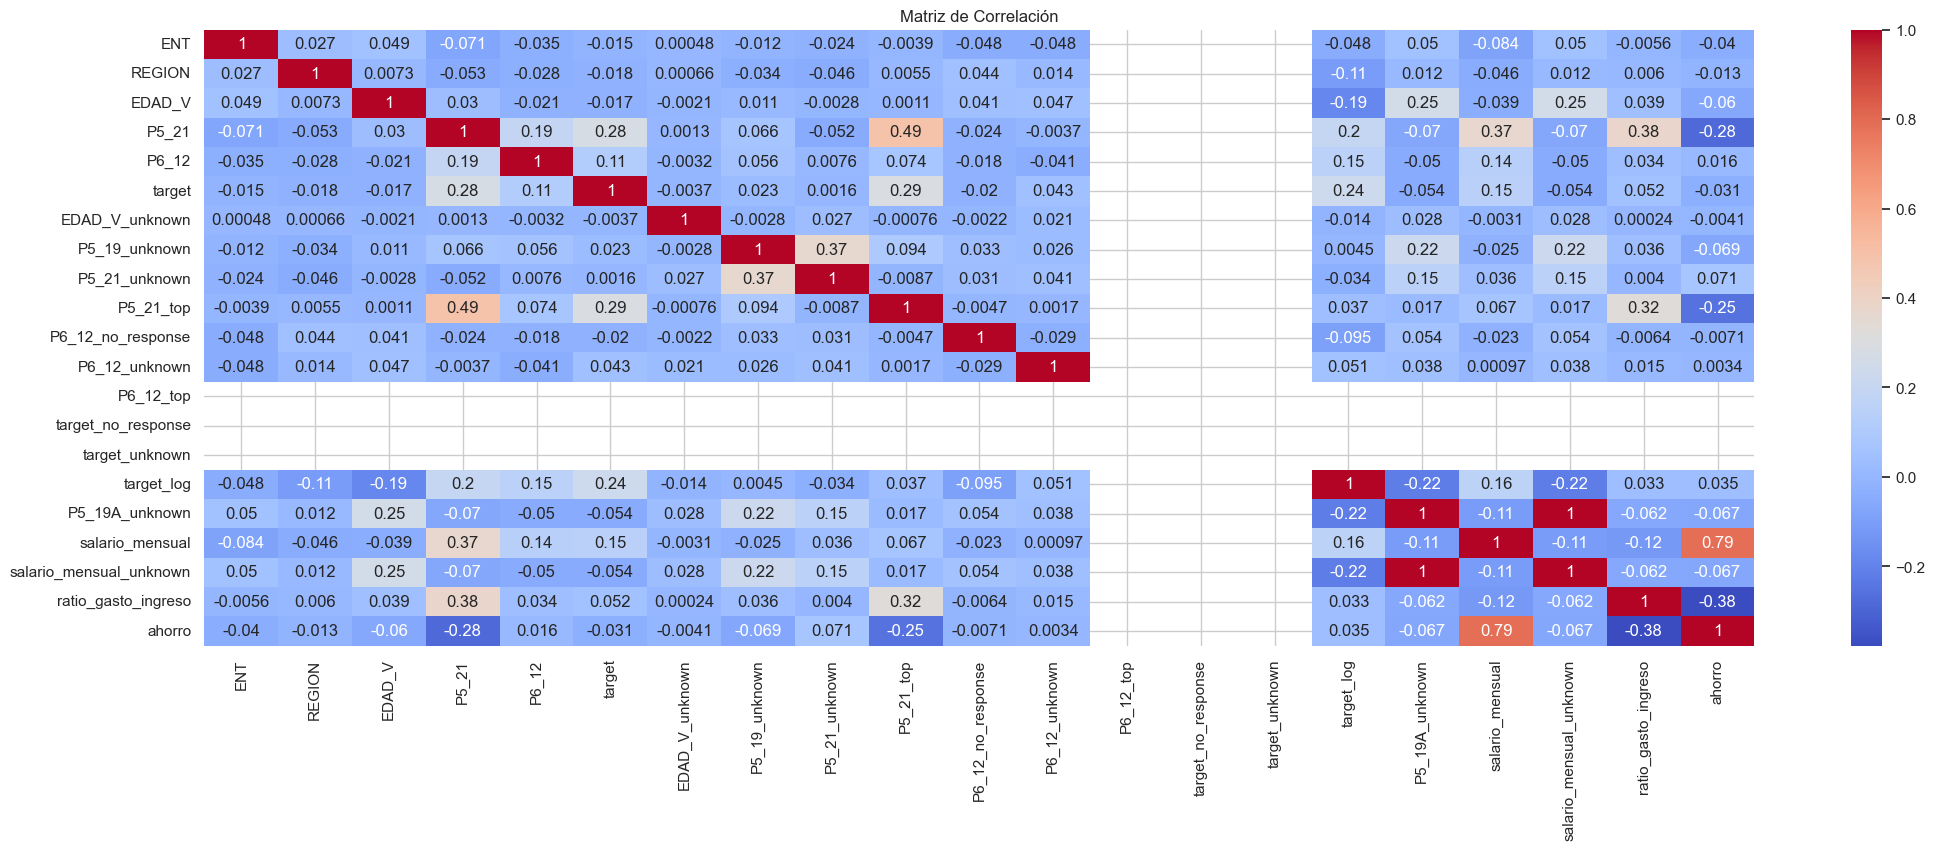

In [47]:
plt.figure(figsize=(25,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

### (Ingresos - Gastos) vs Capacidad de Pago reportada

- Para obtener una estimación de su capacidad de pago, se debe establecer la operacion entre sus ingresos menos los gastos. Esto debería mostrar un porcentaje que no sobre pase la cantidad sobrante con respecto a su capacidad de pago reportada (target_log)


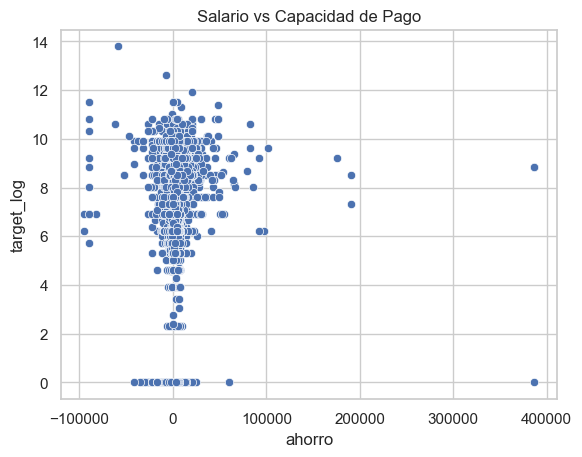

In [40]:
plt.figure()
sns.scatterplot(x=df["ahorro"], y=df["target_log"])
plt.title("Salario vs Capacidad de Pago")
plt.show()